# Market Segmentation Model (Unsupervised Model)

In [2]:
import pandas as pd
import seaborn as sns
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"D:\downloads\consumer_electronics_sales_data.csv")
df

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0
...,...,...,...,...,...,...,...,...,...
8995,14869,Smart Watches,Samsung,1041.149163,36,1,16,4,0
8996,14870,Smartphones,Samsung,1485.694311,57,0,5,1,1
8997,14871,Headphones,Samsung,2887.369597,28,0,18,4,0
8998,14872,Tablets,HP,1490.453964,38,0,4,2,1




#  Pre Processing Part :

# 1- Feature Selection:
# Here we have chosen the continous columns where they have distances we can compare with if the categorical col's be in the cluster alg we will see distortion to the alg.

In [4]:
df_K_Means = df[['CustomerAge','ProductPrice','PurchaseFrequency','CustomerSatisfaction']]

In [5]:
df.columns.to_list()

['ProductID',
 'ProductCategory',
 'ProductBrand',
 'ProductPrice',
 'CustomerAge',
 'CustomerGender',
 'PurchaseFrequency',
 'CustomerSatisfaction',
 'PurchaseIntent']

# 2- Standardization

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_K_Means_scaled = scaler.fit_transform(df_K_Means)

# Tunning
# 1 - Decision best cluster to K-Mean alg where its Elbow Method where we want to find that is my data point is Faraway from my centroid or not by summing distance through all points in the cluster and by max dist that be worse so we need least WCSS and most effieciency to choose our K= NO. of clusters 

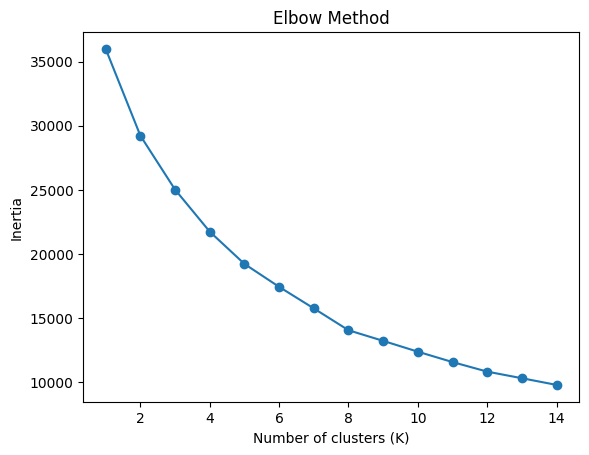

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 15)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=14)
    km.fit(df_K_Means_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


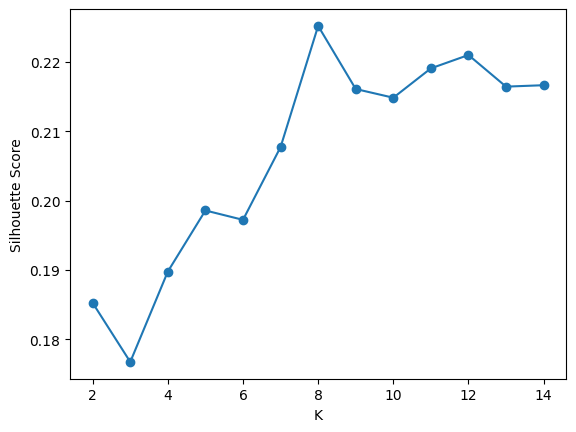

In [8]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(df_K_Means_scaled)
    sil_scores.append(silhouette_score(df_K_Means_scaled, labels))

plt.plot(range(2, 15), sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
final_labels = kmeans.fit_predict(df_K_Means_scaled)
print("Final Silhouette Score:",silhouette_score(df_K_Means_scaled, final_labels))

Final Silhouette Score: 0.225184086808759


# K-Means identified eight customer segments based on Customer Age, Product Price, Purchase Frequency, and Customer Satisfaction. However, the silhouette score of 0.22 indicates relatively weak cluster separation, suggesting that the identified segments overlap considerably and are not highly distinct.

In [10]:
cluster_means = df_K_Means.groupby(final_labels).mean()
cluster_means.index = cluster_means.index + 1
cluster_means.index.name = "Cluster"

display(cluster_means)

,CustomerAge,ProductPrice,PurchaseFrequency,CustomerSatisfaction
Cluster,,,,
1,32.902269,803.020588,5.575916,1.928447
2,30.345337,948.367397,14.329640,4.099723
3,54.477819,2199.941731,14.607209,4.105360
4,54.741906,860.951439,6.625899,4.269784
5,31.081436,2217.934367,5.920315,3.971979
6,54.955075,929.735699,14.194676,1.945092
7,56.012357,2141.821351,5.377758,2.030009
8,31.565455,2167.906697,14.085455,1.772727


In [11]:
final_k = 8   # replace with whatever Steps 4a/4b actually indicated

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(df_K_Means_scaled)

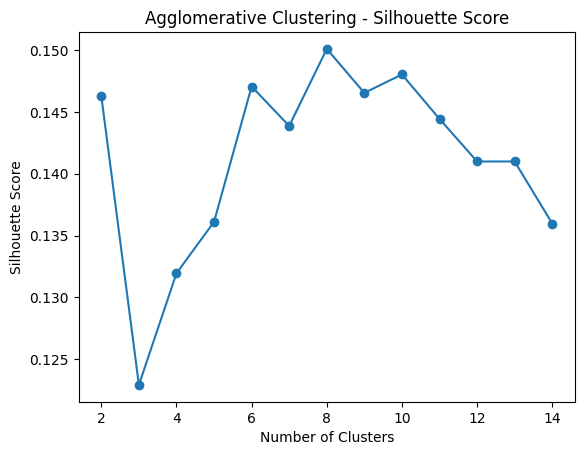

Agglomerative Silhouette Score: 0.15009049933964272


In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agglo = AgglomerativeClustering(n_clusters=final_k)
df['Cluster_Agglo'] = agglo.fit_predict(df_K_Means_scaled)

import matplotlib.pyplot as plt

agglo_scores = []

for k in range(2, 15):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(df_K_Means_scaled)
    agglo_scores.append(
        silhouette_score(df_K_Means_scaled, labels)
    )

plt.plot(
    range(2, 15),
    agglo_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Agglomerative Clustering - Silhouette Score")
plt.show()

agglo_score = silhouette_score(df_K_Means_scaled, agglo.labels_)

print("Agglomerative Silhouette Score:", agglo_score)

In [13]:
df.groupby('Cluster_Agglo')[
    ['CustomerAge',
     'ProductPrice',
     'PurchaseFrequency',
     'CustomerSatisfaction']
].mean()

,CustomerAge,ProductPrice,PurchaseFrequency,CustomerSatisfaction
Cluster_Agglo,,,,
0,37.274068,1116.427517,5.397516,1.624224
1,29.697089,1668.201602,6.291896,4.140834
2,33.919259,1715.597869,14.538054,1.704169
3,57.864060,950.528185,14.698324,2.981378
4,31.276510,1412.610149,16.299329,4.312752
5,55.366300,2125.486471,5.651282,2.460073
6,51.627207,789.828804,7.096573,4.237799
7,54.122605,2377.005736,14.174968,4.061303


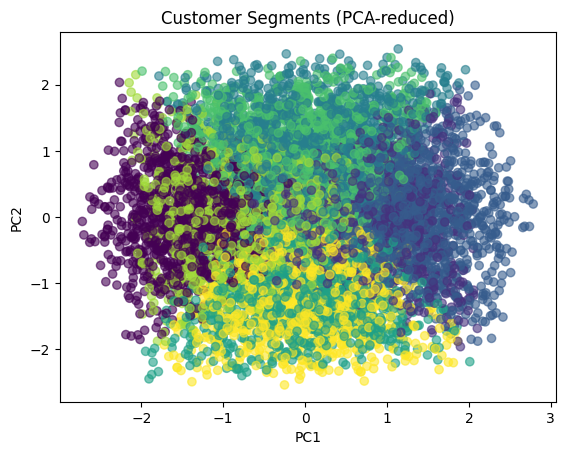

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_K_Means_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster_KMeans'], cmap='viridis', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA-reduced)")
plt.show()

In [15]:
# Behavioral profile — the features actually used for clustering
#df.groupby('Cluster_KMeans')[df_K_Means_scaled].mean()

# Categorical profile — brought back in now, purely for interpretation
#df.groupby('Cluster_KMeans')['CustomerGender'].mean()
#df.groupby('Cluster_KMeans')['ProductBrand'].value_counts(normalize=True)
#df.groupby('Cluster_KMeans')['ProductCategory'].value_counts(normalize=True)

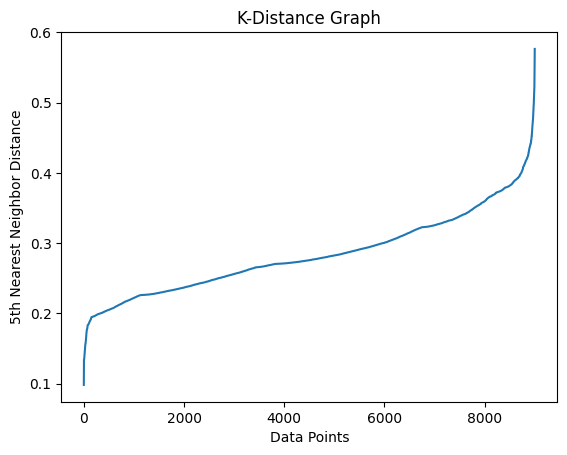

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(df_K_Means_scaled)

distances, indices = neighbors_fit.kneighbors(
    df_K_Means_scaled
)

distances = np.sort(distances[:, 4])

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")
plt.show()

In [17]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=0.35, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(df_K_Means_scaled)

# DBSCAN labels noise points as -1 — check how many you got
n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise = (df['Cluster_DBSCAN'] == -1).sum()
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Silhouette score only makes sense if there's more than 1 cluster and not everything is noise
if n_clusters > 1:
    # exclude noise points when computing silhouette score
    mask = df['Cluster_DBSCAN'] != -1
    score = silhouette_score(df_K_Means_scaled[mask], df['Cluster_DBSCAN'][mask])
    print("DBSCAN Silhouette Score:", score)

Number of clusters found: 12
Number of noise points: 177
DBSCAN Silhouette Score: -0.21544442950737305


In [18]:
df.groupby('Cluster_DBSCAN')[
    ['CustomerAge', 'ProductPrice', 'PurchaseFrequency', 'CustomerSatisfaction']
].mean()

,CustomerAge,ProductPrice,PurchaseFrequency,CustomerSatisfaction
Cluster_DBSCAN,,,,
-1,44.988701,1595.091547,10.389831,2.870056
0,42.947674,1506.182857,9.979651,1.000000
1,43.037917,1508.035583,9.888512,2.000000
2,43.936702,1560.848115,9.916158,3.000000
3,43.448176,1516.386827,10.246091,5.000000
4,43.079141,1534.139555,10.202374,4.000000
5,25.000000,304.355480,17.777778,3.000000
6,44.250000,1168.244273,19.000000,2.000000
7,32.500000,888.995090,1.000000,1.000000
